In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../results/preliminary")

PARAM_NAMES = ["beta", "gamma", "rho"]

PARAM_LABELS = {
    "beta": r"$\beta$",
    "gamma": r"$\gamma$",
    "rho": r"$\rho$"
}

EPS = [0.1, 0.01, 0.001]

SUMMARY_NAMES = [
    "mean:auc_infected_fraction",
    "mean:peak_infected_fraction",
    "mean:time_to_peak_infected_fraction",
    "mean:peak_rewire_count",
    "mean:total_rewire_count",
    "mean:mean_degree",
    "mean:sd_degree"
]

In [2]:
# Read in the data
reference_table = pd.read_csv(DATA_DIR / "sim/reference_table.csv")
obs_data = pd.read_csv(DATA_DIR / "raw/observed_stats_raw.csv")

full_stats = reference_table[SUMMARY_NAMES].values
full_params = reference_table[PARAM_NAMES].values

obs_stats = obs_data[SUMMARY_NAMES].values

print(full_stats.shape)
print(obs_stats.shape)

(100000, 7)
(1, 7)


In [3]:
from scipy.stats import gaussian_kde
from scipy.stats import kstest

def robust_mode_3d(data, bins=30, refine_percentile=10):
    """
    Robust mode estimate for 3D continuous data using 2-stage histogram + refinement.

    Parameters:
    - data: (N, 3) array
    - bins: coarse histogram resolution
    - refine_percentile: fraction of points kept around peak region

    Returns:
    - mode estimate (3,)
    """

    # ---------------------------
    # Step 1: coarse histogram
    # ---------------------------
    hist, edges = np.histogramdd(data, bins=bins)
    idx = np.unravel_index(np.argmax(hist), hist.shape)

    # ---------------------------
    # Step 2: extract points in densest bin
    # ---------------------------
    mask = np.ones(len(data), dtype=bool)
    for i in range(3):
        mask &= (
            (data[:, i] >= edges[i][idx[i]]) &
            (data[:, i] < edges[i][idx[i] + 1])
        )

    core = data[mask]

    # fallback if bin is too sparse
    if len(core) < 10:
        return data.mean(axis=0)

    # ---------------------------
    # Step 3: refine using nearest points
    # ---------------------------
    center = core.mean(axis=0)
    dist = np.linalg.norm(data - center, axis=1)

    cutoff = np.percentile(dist, refine_percentile)
    refined = data[dist <= cutoff]

    # final estimate
    return refined.mean(axis=0)

def compute_posterior_estimates(accepted_params):
    posterior_mean = np.mean(accepted_params, axis=0)
    posterior_median = np.median(accepted_params, axis=0)

    posterior_mode = robust_mode_3d(accepted_params)

    return {
        "mean": posterior_mean,
        "median": posterior_median,
        "mode": posterior_mode
    }


In [8]:
# Perform Rejection ABC for epsilon = 0.1, 0.01, 0.001
# - Normalization: mean->zero, sd->1
# - Distance: Euclidean (continuous data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(full_stats)

full_stats_scaled = scaler.transform(full_stats)
obs_stats_scaled = scaler.transform(obs_stats)

distances = np.linalg.norm(full_stats_scaled - obs_stats_scaled, axis=1)

results = {}
result_list = []
for eps in EPS:
    k = int(eps * len(distances))
    delta = np.partition(distances, k)[k]

    idx = distances <= delta
    accepted_params = full_params[idx]
    accepted_stats = full_stats_scaled[idx]

    posterior_estimates = compute_posterior_estimates(accepted_params)

    results[eps]= {
        "accepted_params": accepted_params,
        "posterior_estimates": posterior_estimates
    }

    result_list.append(results[eps])
    


In [9]:
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.stats import mode as scipy_mode
from itertools import combinations

# ── colour palette (consistent across all plots) ──────────────────────────
EPSILON_COLORS = {
    0.001: "#111111",   # dark gray
    0.01:  "#333333",        # gray
    0.1:   "#666666",        # light gray
}
EPSILON_LABELS = {
    0.001: "0.001",
    0.01:  "0.01",
    0.1:   "0.1"
}
PARAM_LABELS = {
    "beta":  r"$\beta$",
    "gamma": r"$\gamma$",
    "rho":   r"$\rho$",
}

PARAM_PRIORS = {
    "beta":  (0.05, 0.5),
    "gamma": (0.02, 0.20),
    "rho":   (0.0, 0.80)
}

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Marginal KDE plots — one panel per parameter, all methods overlaid
# ══════════════════════════════════════════════════════════════════════════════
def plot_marginal_kdes(results, eps, save_path="marginal_kdes.pdf"):
    fig, axes = plt.subplots(1, len(PARAM_NAMES), figsize=(4.5 * len(PARAM_NAMES), 3.5))

    for ax, param in zip(axes, PARAM_NAMES):
        pidx = PARAM_NAMES.index(param)

        a, b = PARAM_PRIORS[param]
        ax.hlines(
            y=1/(b-a),
            xmin=a,
            xmax=b,
            color="blue",
            linestyle="--",
            linewidth=0.75,
            alpha=0.4,
            label="prior",
        )
        for e in eps:
            samples = results[e]["accepted_params"][:, pidx]
            kde     = gaussian_kde(samples, bw_method="scott")
            xs      = np.linspace(samples.min(), samples.max(), 400)
            ax.plot(xs, kde(xs),
                    color=EPSILON_COLORS[e],
                    label=EPSILON_LABELS[e],
                    linestyle="--",
                    linewidth=(1.75 if e == 0.001 else 0.75))

        ax.set_xlabel(PARAM_LABELS[param], fontsize=12)
        ax.set_ylabel("Density" if param == PARAM_NAMES[0] else "", fontsize=11)
        ax.tick_params(labelsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="right",
               fontsize=9)

    fig.tight_layout()
    fig.suptitle(r"Rejection ABC", fontsize=12, y=1.01)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig

# ══════════════════════════════════════════════════════════════════════════════
# 2.  RF posterior summary table  (mode, mean, median, 95 % HPD)
# ══════════════════════════════════════════════════════════════════════════════
def hpd_interval(samples, credmass=0.95):
    """Highest posterior density interval via sorted window."""
    sorted_s = np.sort(samples)
    n        = len(sorted_s)
    window   = int(np.floor(credmass * n))
    widths   = sorted_s[window:] - sorted_s[:n - window]
    idx      = np.argmin(widths)
    return sorted_s[idx], sorted_s[idx + window]

def kde_mode(samples):
    kde = gaussian_kde(samples, bw_method="scott")
    xs  = np.linspace(samples.min(), samples.max(), 2000)
    return xs[np.argmax(kde(xs))]

def build_rf_summary_table(results, eps):
    rows = []
    for e in eps:
        for param in PARAM_NAMES:
            pidx    = PARAM_NAMES.index(param)
            samples = results[e]["accepted_params"][:, pidx]
            lo, hi  = hpd_interval(samples, 0.95)
            rows.append({
                r"$\varepsilon$": e, 
                "Parameter": PARAM_LABELS[param],
                "Mode":      f"{kde_mode(samples):.4f}",
                "Mean":      f"{samples.mean():.4f}",
                "Median":    f"{np.median(samples):.4f}",
                "95% HPD interval": f"({lo:.4f}, {hi:.4f})",
            })
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  RF pairwise joint posterior plot
# ══════════════════════════════════════════════════════════════════════════════
def plot_pairwise_joint(accepted_samples, eps, save_path="base_pairwise_joint.pdf"):
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import gaussian_kde

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()


    for i in range(3):
        param = PARAM_NAMES[i]
        pidx = PARAM_NAMES.index(param)
        qidx = (pidx + 1) % 3

        ax = axes[i]

        # KDE joint density (row 1)
        accepted = accepted_samples
        x, y = accepted[:, pidx], accepted[:, qidx]
        k = gaussian_kde(np.vstack([x, y]), bw_method="scott")

        xg = np.linspace(x.min(), x.max(), 80)
        yg = np.linspace(y.min(), y.max(), 80)
        X, Y = np.meshgrid(xg, yg)
        Z = k(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        ax.contourf(X, Y, Z, levels=6, cmap="Greys", alpha=0.85)
        cs = ax.contour(X, Y, Z, levels=6, colors="black", linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

        # mode
        max_idx = np.unravel_index(np.argmax(Z), Z.shape)
        mode_x = X[max_idx]
        mode_y = Y[max_idx]

        ax.scatter(mode_x, mode_y, color="red", s=40, zorder=5)

        # label with numeric value
        label = f"({mode_x:.2f}, {mode_y:.2f})"

        ax.annotate(
            label,
            xy=(mode_x, mode_y),
            xytext=(10, 10),
            textcoords="offset points",
            color="red",
            fontsize=9,
        )

        ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pidx]], fontsize=10)
        ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[qidx]], fontsize=10)

    # Row 2: scatter plots
    for i in range(3):
        ax = axes[3 + i]

        pidx = i
        qidx = (i + 1) % 3

        x, y = accepted[:, pidx], accepted[:, qidx]

        max_points = 1000
        idx = np.random.default_rng(0).choice(len(x), min(len(x), max_points), replace=False)
        ax.scatter(x[idx], y[idx], alpha=0.3, color="black")

        ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pidx]], fontsize=10)
        ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[qidx]], fontsize=10)

    fig.suptitle(r"Rejection ABC, $\varepsilon = $" + f"{eps}", fontsize=12)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"Saved: {save_path}")
    return fig


Saved: ..\results\preliminary\base_marginal_posterior.png

RF posterior summary
 $\varepsilon$ Parameter   Mode   Mean Median 95% HPD interval
         0.100   $\beta$ 0.1699 0.2181 0.2055 (0.0753, 0.3849)
         0.100  $\gamma$ 0.1020 0.1261 0.1254 (0.0606, 0.2000)
         0.100    $\rho$ 0.2826 0.2578 0.2635 (0.0368, 0.4637)
         0.010   $\beta$ 0.1563 0.1535 0.1529 (0.0981, 0.2129)
         0.010  $\gamma$ 0.0990 0.1174 0.1126 (0.0615, 0.1804)
         0.010    $\rho$ 0.2689 0.2545 0.2573 (0.1273, 0.3857)
         0.001   $\beta$ 0.1304 0.1376 0.1347 (0.1066, 0.1718)
         0.001  $\gamma$ 0.0987 0.1008 0.1000 (0.0715, 0.1268)
         0.001    $\rho$ 0.2440 0.2473 0.2464 (0.1786, 0.3155)
Saved: ..\results\preliminary\base_pairwise_joint.png


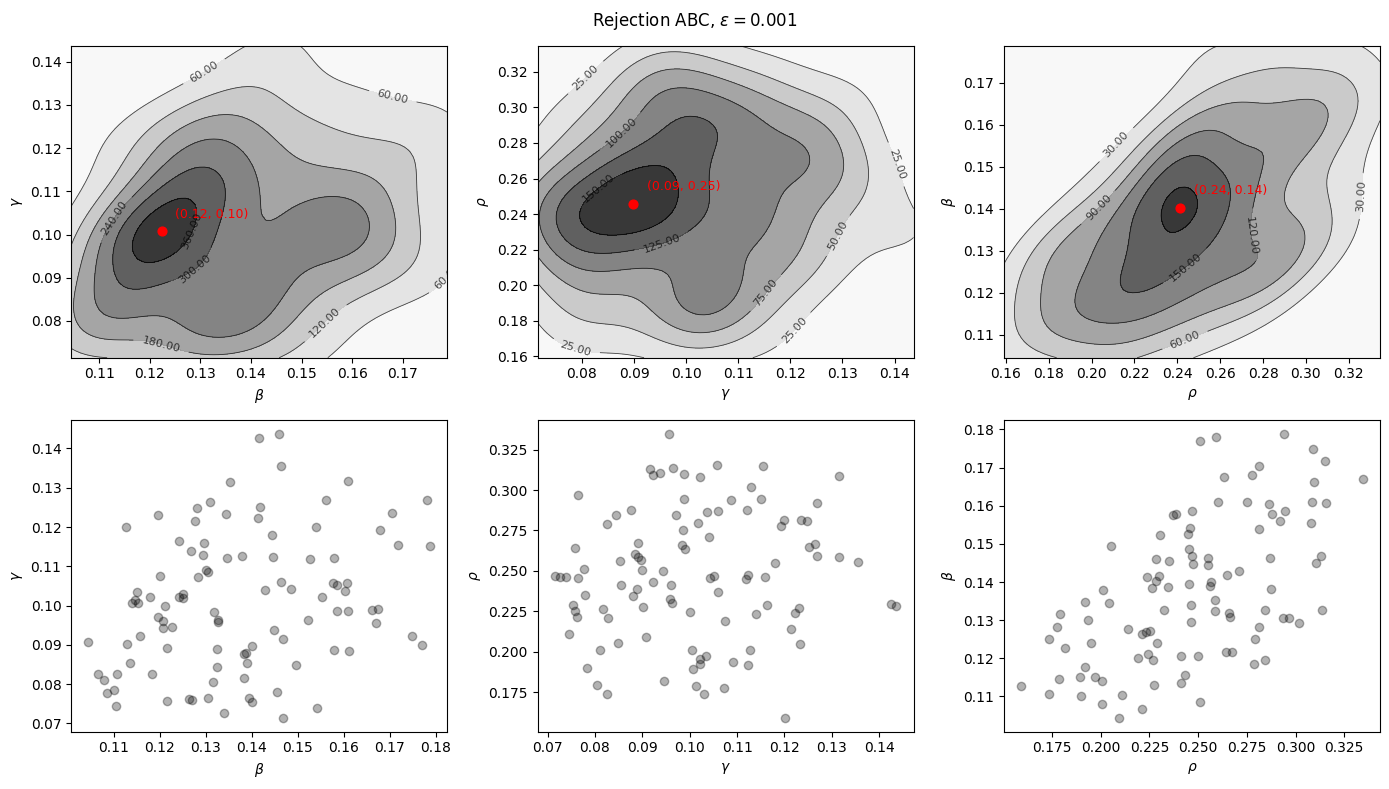

In [10]:
# ── 1. Marginal KDEs ──────────────────────────────────────────────────
eps = 0.001
accepted_params = results[eps]["accepted_params"]

plot_marginal_kdes(results, EPS,
                    save_path=OUTPUT_DIR / "base_marginal_posterior.png")

# ── 2. RF summary table ───────────────────────────────────────────────
base_summary = build_rf_summary_table(results, EPS)
print("\nRF posterior summary")
print(base_summary.to_string(index=False))
base_summary.to_csv(OUTPUT_DIR / "base_posterior_summary.csv", index=False)

# ── 3. Pairwise joint posterior ───────────────────────────────────────
plot_pairwise_joint(accepted_params, eps,
                    save_path=OUTPUT_DIR / "base_pairwise_joint.png")

In [11]:
accepted_params = results[eps]["accepted_params"]
np.save(OUTPUT_DIR / "base_posterior_samples.npy", accepted_params)